In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystem, GlobalSystemThreshold

In [2]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [3]:
# Random distribution
np.random.seed(0)

# Set limits of characteristic size of chamber
R_min = 500
R_max = 500
# Uniformly randomly distribution volume
V_min = (4/3)*np.pi*R_min**3
V_max = (4/3)*np.pi*R_max**3

# List generation of chamber characteristics
x_nodes = 0.0 * np.random.rand(N_chamber)
y_nodes = 0.0 * np.random.rand(N_chamber)
z_nodes = np.linspace(0.0, z_scale, N_chamber)
V_nodes = V_min + (V_max - V_min) * np.random.rand(N_chamber)

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=None,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [ ]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=0.0,#1e2,
                                   R_outer_ratio=20,)

q0 = global_sys.q0

# Compute initial L, M(q0), f
L, M, f = global_sys.assemble_global_LMf(q0)

# Time vector
N_t:int=7500#30000
t_vec = None
if t_vec is None:
  t1 = 15e10
  # t_vec = np.array([*np.linspace(0, t1, N_t+1), *np.linspace(t1, t2, N_t+1)[1:]])
  t_vec = np.linspace(0, t1, N_t)


In [60]:
# Set mass rate for injection
mdot_inj = 3.0
# Add source term for injection
f_inj = 0.0 * f
f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj

# Eruption parameters
r_conduit = 25
mu_erupt = 1e5
# Overpressure required for eruption
p_erupt = 5e6

In [61]:
''' Timestepping '''

# Start q with initial condition
q = q0.copy()
# Allocate full output storage
q_out = np.zeros((t_vec.size, *q.shape))
# Save last dt for cache check
dt = np.nan
dt_last = np.nan
dt_last_last = np.nan
# Max order possible
max_order = np.ones(t_vec.size, dtype=int)

global_sys._step_strategy = np.zeros(t_vec.size, dtype=float)
L, M, f = global_sys.assemble_global_LMf(q)
# lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)

m_erupted = 0.0
m_erupted_out = np.zeros((t_vec.size,))

for i, t in enumerate(t_vec):
  if i > 0:
    # Compute timestep
    dt = t_vec[i] - t_vec[i-1]

    M = global_sys.assemble_global_LMf(q, skip_Lf=True)

    # Strang split      
    # q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * L, q + f * dt)

    p_node = global_sys.pressure(q)
    
    deltap = (p_node[-1] - global_sys.nodes[-1].p0) - p_erupt
    f_erupt = 0.0 * f_inj
    if deltap > 0:
      eruption_rate = global_sys.rho0 * (deltap / (16.0 * mu_erupt)) * r_conduit * r_conduit * r_conduit
      # Eruption rate limiter for first-order Euler
      # Volatile-free estimate for pressure-equilibrium mass
      # Assumes hysteresis (empties down to zero overpressure)
      # This is a key parameter for inter-eruption time
      V0 = 4*np.pi*global_sys.nodes[-1].R0**3/3
      dV = global_sys.u(q)[-1,0] * (4 * np.pi * global_sys.nodes[-1].R0**2)
      max_eruption_rate = (q[global_sys.data_slice_global(-1, "mass")] - (V0 + dV) / V0 * global_sys.nodes[-1].m0) / dt
      if eruption_rate > max_eruption_rate:
        eruption_rate = max_eruption_rate
      # Set eruption rate in mass conservation equation
      f_erupt[global_sys.data_slice_global(-1, "mass")] = -eruption_rate
      
      # Integrate erupted mass
      m_erupted += eruption_rate * dt

    # Quasi-implicit one-step solve (strictly M(q^n) is used instead of M(q^n+1))
    q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * (L + M), q + dt * (f + f_inj + f_erupt))[:,np.newaxis]

    if False:
      # (1/3) BDF1, update matrix inv(I + dt*L)
      # lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + 0.5 * dt * L)
      q = lu_out.solve(q + f * 0.5 * dt)
      # (2/3) Semi-BDF1, update matrix (approximate threshold explicitly, not implicitly)
      q = scipy.sparse.linalg.spsolve(scipy.sparse.eye(global_sys.num_dof) + dt * M, q)[:,np.newaxis]
      # (3/3) BDF1, update matrix inv(I + dt*L)
      q = lu_out.solve(q + f * 0.5 * dt)
      global_sys._step_strategy[i] = 1.0

    if False:
      if method == 2 and np.isclose(dt, dt_last) and not np.isclose(dt_last_last, dt_last):
        # BDF2, update matrix
        lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + (2.0/3.0) * dt * L)
        q = lu_out.solve((4.0/3.0) * q + (2.0/3.0) * f * dt - (1.0/3.0) * q_out[i-2,...])
        global_sys._step_strategy[i] = 2.0
      elif method == 2 and np.isclose(dt, dt_last) and np.isclose(dt_last_last, dt_last):
        # BDF2, use cached matrix
        q = lu_out.solve((4.0/3.0) * q + (2.0/3.0) * f * dt - (1.0/3.0) * q_out[i-2,...])
        global_sys._step_strategy[i] = 2.5
      elif not np.isclose(dt, dt_last):
        # BDF1, update matrix inv(I + dt*L)
        lu_out = scipy.sparse.linalg.splu(scipy.sparse.eye(global_sys.num_dof) + dt * L)
        q = lu_out.solve(q + f * dt)
        global_sys._step_strategy[i] = 1.0
      else:
        # BDF1, use cached matrix inv(I + dt*L)
        q = lu_out.solve(q + f * dt)
        global_sys._step_strategy[i] = 1.5

  dt_last_last = dt_last
  dt_last = dt
  q = np.reshape(q, (q.size, 1))
  # Save result
  q_out[i,...] = q
  m_erupted_out[i] = m_erupted


In [63]:
# Post-process with output size (n_t, n_chambers, (N_r))
m, p, sigmas, u = global_sys.post_process(t_vec, q_out)

Time index 1500. Chambers are in a 2D plane. 
Time index 4500. Chambers are in a 2D plane. 
Time index 7500. Chambers are in a 2D plane. 
Time index 13500. Chambers are in a 2D plane. 


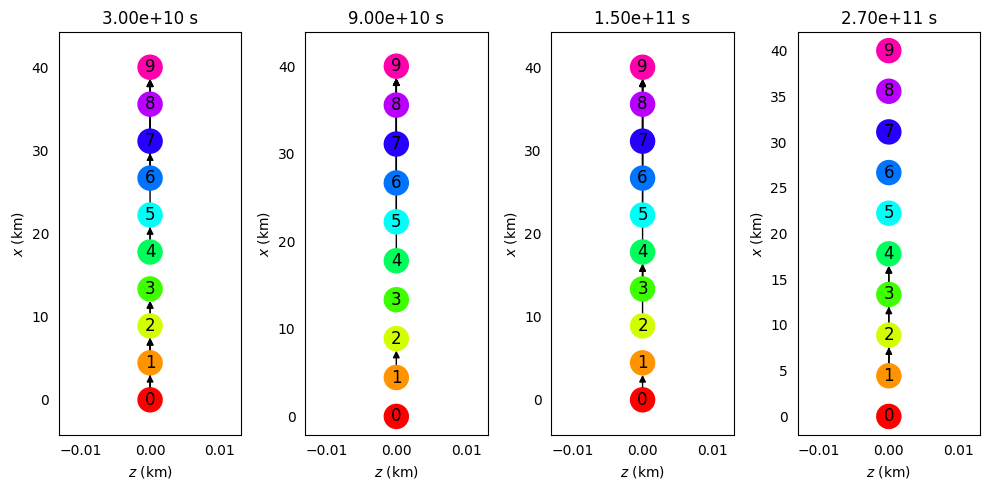

In [64]:
t_select_index = 0

fig, ax = plt.subplots(1, 4, figsize=(10,5), dpi=100)
index_array = (t_vec.size * np.array([0.1, 0.3, 0.5, 0.9])).astype(int)
for i, t_select_index in enumerate(index_array):
  global_sys.show_network(q_out[t_select_index,:], ax=ax[i], node_scale=300)
  print(f"Time index {t_select_index}. Chambers are in a 2D plane. ")
  ax[i].set_title(f"{t_vec[t_select_index]:.2e} s")
fig.set_tight_layout(True)

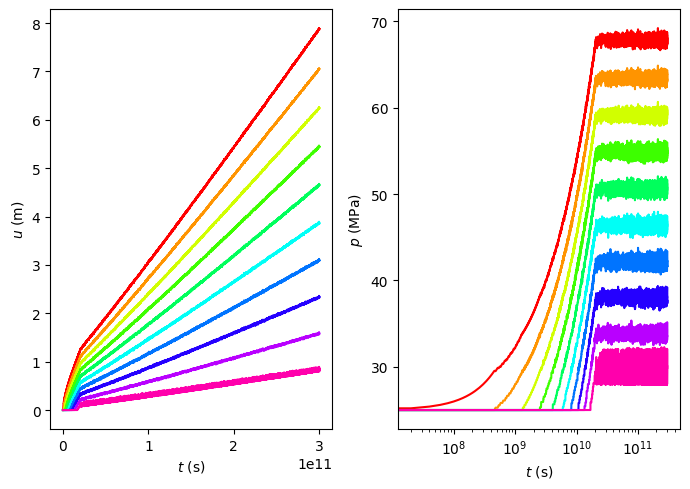

In [65]:
''' Wall displacement, pressure in each chamber '''
fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=100)
cmap = matplotlib.cm.hsv
colors = cmap(np.linspace(0,1,global_sys.num_blocks,endpoint=False))

for i in range(p.shape[1]):
  ax[0].plot(t_vec, u[:,i,0], color=colors[i])
ax[0].set_xlabel("$t$ (s)")
ax[0].set_ylabel("$u$ (m)")

for i in range(p.shape[1]):
  ax[1].semilogx(t_vec, p[:,i] / 1e6, color=colors[i])
ax[1].set_xlabel("$t$ (s)")
ax[1].set_ylabel("$p$ (MPa)")

fig.tight_layout()

(22000000000.0, 23000000000.0)

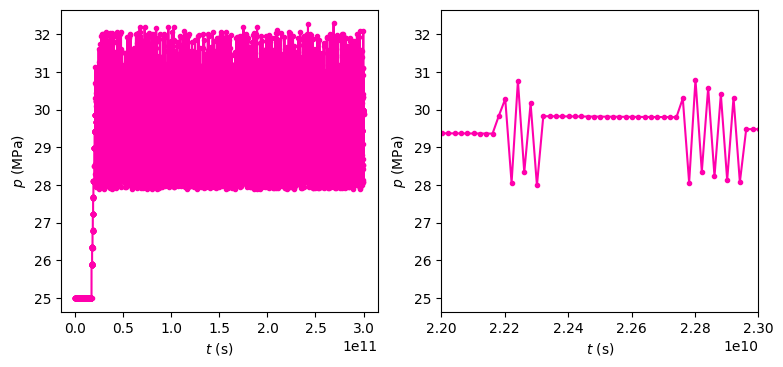

In [66]:

plt.figure(figsize=(9,4),dpi=100)

plt.subplot(1,2,1)
plt.plot(t_vec, p[:,-1] / 1e6, '.-', color=colors[i])
plt.xlabel("$t$ (s)")
plt.ylabel("$p$ (MPa)")

plt.subplot(1,2,2)

plt.plot(t_vec, p[:,-1] / 1e6, '.-', color=colors[i])
plt.xlabel("$t$ (s)")
plt.ylabel("$p$ (MPa)")
plt.xlim(2.2e10, 2.3e10)

In [ ]:
# gamma_drr_t = q_out[-1,global_sys.data_slice_global(-1, "gamma_drr"),0]
# gamma_kk_t = q_out[-1,global_sys.data_slice_global(-1, "gamma_kk"),0]
# gamma_rr_t = gamma_drr_t + gamma_kk_t / 3.0
# gamma_rr_t_wall = gamma_rr_t[0]

# V0 = 4*np.pi*global_sys.nodes[-1].R0**3/3
# dV = global_sys.u(q_out[-1,:])[-1,0] * (4 * np.pi * global_sys.nodes[-1].R0**2)
# V0, dV

ValueError: could not interpret dimensions

In [ ]:
# (V0 + dV) / V0 * node.m0, node.m0

(613080993244.1895, 610283434656.9756)

Text(0, 0.5, '$\\Delta m$ (kg)')

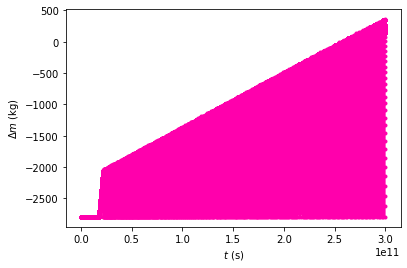

In [ ]:
# plt.plot(t_vec, (m[:,-1] - (V0 + dV) / V0 * global_sys.nodes[-1].m0) / 1e6, '.-', color=colors[i])
# plt.xlabel("$t$ (s)")
# plt.ylabel("$\Delta m$ (kg)")
# plt.xlim(25.0e10, 25.3e10)

Text(0, 0.5, '$\\Delta m$ (kg)')

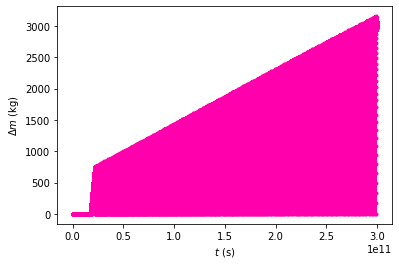

In [ ]:
# plt.plot(t_vec, (m[:,-1] - node.m0) / 1e6, '.-', color=colors[i])
# plt.xlabel("$t$ (s)")
# plt.ylabel("$\Delta m$ (kg)")
# plt.xlim(25.0e10, 25.3e10)

Text(0, 0.5, '$p$ (MPa)')

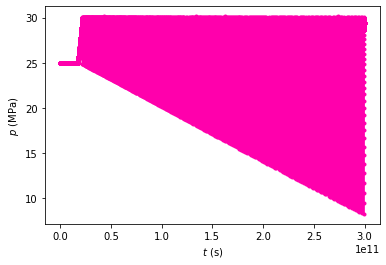

In [56]:
plt.plot(t_vec, p[:,-1] / 1e6, '.-', color=colors[i])
plt.xlabel("$t$ (s)")
plt.ylabel("$p$ (MPa)")
# plt.xlim(25.0e10, 25.3e10)

Text(0, 0.5, '$\\Delta t/dt$')

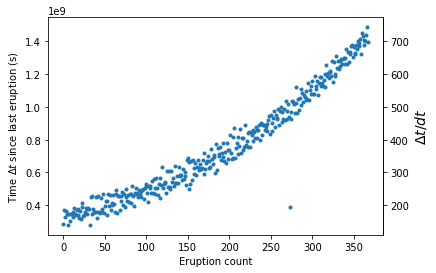

In [11]:
# Estimate dpdt
t_cell = 0.5 * (t_vec[:-1] + t_vec[1:])
dt_vec = t_vec[1:] - t_vec[:-1]
dpdt = np.diff(p[:,-1]) / dt_vec
t_idx_eruption = np.where(dpdt < - 1)
plt.plot(np.diff(t_cell[t_idx_eruption]), '.')
plt.xlabel("Eruption count")
plt.ylabel("Time $\Delta t$ since last eruption (s)")
ax2y = plt.gca().secondary_yaxis('right', functions=(
  lambda t: t / (dt_vec[0]),
  lambda tau: tau * dt_vec[0]))
ax2y.set_ylabel('$\Delta t/dt$', fontsize=14)

In [12]:
z_sample_mesh = np.linspace(0, z_scale, 20)
mdot_grid = np.zeros((q_out.shape[0], z_sample_mesh.size))

def eval_mdot_contribution(tup, z):
  ''' Evaluate contribution to mass rate of a particular pairwise flow at location x.
  Input:
    tup: tuple containing (z_0, z_1, and mdot from chamber 0 to chamber 1 )
    z: depth to evaluate at '''
  # Check whether z is between z_0 and z_1
  z_min = 0.5 * (tup[0] + tup[1]) - 0.5 * np.abs(tup[1] - tup[0])
  z_max = 0.5 * (tup[0] + tup[1]) + 0.5 * np.abs(tup[1] - tup[0])
  if z <= z_max and z >= z_min:
    # Evaluate sign modification based on geometry
    sign = np.sign(tup[1] - tup[0])
    return sign * tup[2]
  else:
    return 0.0

def mdot_total(tups, z):
  mdot = np.zeros_like(z, dtype=float)
  for i, z_i in enumerate(z):
    mdot[i] = sum([eval_mdot_contribution(tup, z_i) for tup in tups])
  return mdot

for time_idx in range(q_out.shape[0]):
  # Extract global state vector
  q = q_out[time_idx,:]
  # Compute pressure of each node
  p_node = global_sys.pressure(q)

  # Assemble of triples (z_1, z_2, mdot) characterizing transport in the z-direction
  transports = []
  for i in range(global_sys.num_blocks):
    node_i = global_sys.nodes[i]
    for j in range(i+1, global_sys.num_blocks):
      node_j = global_sys.nodes[j]

      # Compute distance
      dist = float(np.sqrt((node_i.x - node_j.x) ** 2
                    + (node_i.y - node_j.y) ** 2
                    + (node_i.z - node_j.z) ** 2))
      # Compute average pressure gradient
      dpdx = (p_node[i] - p_node[j]) / dist
      # Factor between (0, 1) that modulates flow between the two chambers
      threshold_factor = float(cnetwork.smoother(np.abs(dpdx) - global_sys.dpdx_crit,
                                  global_sys.dpdx_threshold_scale))
      if threshold_factor > 1 or threshold_factor < 0:
        raise ValueError
      if threshold_factor > 1e-15:
        # Compute flow admittance ( (m/s) / Pa ) -- sign is determined automatically by multiplication with state vector q
        Y = threshold_factor * global_sys.r_hydr * global_sys.r_hydr / 16.0 / global_sys.mu0 / dist
        # Multiply mass rate coefficient (kg / s) by dimensionless flow matrix M_loc
        M_loc = (Y * global_sys.rho0 * global_sys.K_f) * global_sys.M_stencils[(i,j,)]
      else:
        M_loc = 0.0 * global_sys.M_stencils[(i,j,)]

      ind_m_i = i*global_sys.block_size + 2*global_sys.Nr
      ind_m_j = j*global_sys.block_size + 2*global_sys.Nr

      # if np.abs((M_loc @ q)[ind_m_j]) > 0:
        # Print pairwise mass transfer if nonzero
        # print((M_loc @ q)[ind_m_i], (M_loc @ q)[ind_m_j])
      mdot_i = float((M_loc @ q)[ind_m_i])
      if mdot_i*mdot_i > 0:
        transports.append((node_i.z, node_j.z, mdot_i,))

  mdot_grid [time_idx,:] = mdot_total(transports, z_sample_mesh)

# plt.plot(mdot_total(transports, z_sample_mesh))
# transports, mdot_total(transports, z_sample_mesh)

Shown: mass transfer timescale
Deviatoric Maxwell time = 5.000000e+10 s


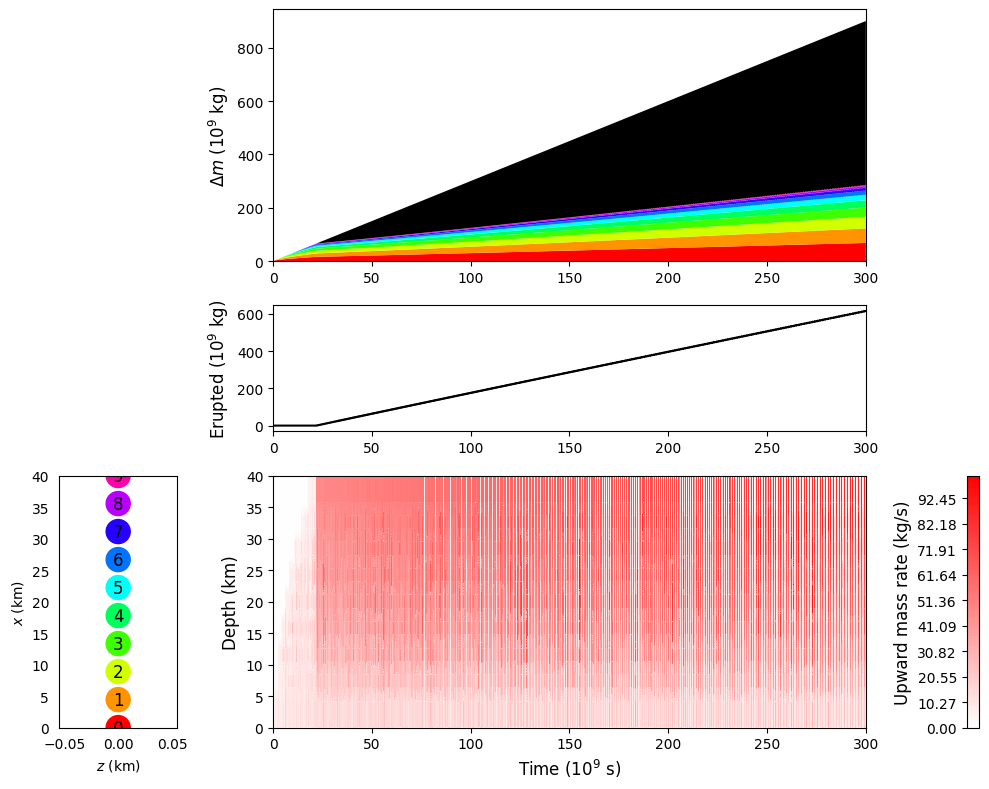

In [13]:
fig = plt.figure(figsize=(11,8), dpi=100)
gridspec = fig.add_gridspec(3, 3, width_ratios=[1, 5, 1],
    height_ratios=[2, 1, 2])
ax = [fig.add_subplot(gridspec[0,1]),
      fig.add_subplot(gridspec[1,1]),
      fig.add_subplot(gridspec[2,0]),
      fig.add_subplot(gridspec[2,1]),
      fig.add_subplot(gridspec[2,2]),]

# Delta mass, lifted to zero
include_erupted_mass = True
t_plot_scale = 1e9
m_plot_scale = 1e9
if include_erupted_mass:
  # Augment data with erupted mass time series
  m_bars_data = np.concatenate((m.T, m_erupted_out[np.newaxis,:]), axis=0)
  colors_aug = np.concatenate((colors, [[0,0,0,1]]), axis=0)
  polys = ax[0].stackplot(t_vec/t_plot_scale,
                          (m_bars_data - m_bars_data.min(axis=1, keepdims=True))/m_plot_scale,
                          colors=colors_aug)
else:
  polys = ax[0].stackplot(t_vec/t_plot_scale,
                          (m.T - m.T.min(axis=1, keepdims=True))/m_plot_scale,
                          colors=colors)
ax[0].set_ylabel("$\Delta m$ ($10^9$ kg)", fontsize=12)
ax[0].set_xlim(t_vec[0]/1e9, t_vec[-1]/1e9)

# Total mass erupted plot
ax[1].plot(t_vec/t_plot_scale, m_erupted_out/m_plot_scale, 'k')
ax[1].set_ylabel("Erupted ($10^9$ kg)", fontsize=12)
ax[1].set_xlim(t_vec[0]/1e9, t_vec[-1]/1e9)

# Adjust clim for mass rate plot
clim = (mdot_grid.min(), mdot_grid.max(),)
shift_div_cmap = cnetwork.zero_aligned_cmap(clim)
if clim[1] - clim[0] ==0 :
  print("Data values are all zero. Skipping mass rate spatial plot.")

else:
  plt.sca(ax[3])

  mg_t, mg_z = np.meshgrid(t_vec, z_sample_mesh)
  plt.contourf(mg_t/1e9, mg_z/1e3, mdot_grid.T, cmap=shift_div_cmap, levels=np.linspace(clim[0], clim[1], 100))
  cb = plt.colorbar(ax=ax[4], location='left')#, ax=ax[:])
  ax[4].set_visible(False)
  cb.set_label("Upward mass rate (kg/s)", fontsize=12)
  plt.xlabel("Time ($10^9$ s)", fontsize=12)
  plt.ylabel("Depth (km)", fontsize=12)

  fig.tight_layout()

  print("Shown: mass transfer timescale")
  print(f"Deviatoric Maxwell time = {t_d:e} s")

  global_sys.show_network(q_out[0,:], ax=ax[2], node_scale=300)
  ax[2].set_ylim(0, z_scale/1e3)

fig.set_tight_layout(True)